In [2]:
import scanpy as sc
import numpy as np
from anndata import AnnData
from scipy.stats import rankdata
from tqdm import tqdm
from functools import partial
from scipy.sparse import csr_matrix

# Read the data

The `counts_combined_filtered_BA4_sALS_PN.h5ad` dataset has to be downloaded at the root of the repository.


In [3]:
adata = sc.read_h5ad("counts_combined_filtered_BA4_sALS_PN.h5ad")

A quick dataset exploration shows that it contains 100k+ cells, 20k+ genes, has two conditions (healthy and ALS) for the BA4 region, and contains already-annotated cell-types.


In [14]:
print("Dataset shape:", adata.shape)
print("Conditions:", adata.obs.Condition.unique().tolist())
print("Cell types:", adata.obs.CellType.unique().tolist())
print("Region:", adata.obs.Region.unique().tolist())

Dataset shape: (112014, 22832)
Conditions: ['ALS', 'PN']
Cell types: ['L5', 'L3_L5', 'L2_L3', 'L4_L6', 'L4_L5', 'L5_L6', 'L6', 'PV', '5HT3aR', 'Rosehip', 'SOM', 'Oligo', 'Astro', 'OPC', 'Micro', 'T_Cell', 'Mural', 'Endo', 'Fibro']
Region: ['BA4']


# In-silico perturbation

We provide two lists of genes to up and down-regulate.

For up-regulated genes, we update their relative rank based on `r -> r ** strengh` (`r` being the relative rank of a given gene). Then, we update the gene expression based on the expression the gene would have according to the updated rank.

> NB: we operate on expression normalized across genes, to account for the bias of the genes expression scales.

For the down-regulation, the same logic goes, but with `r -> r ** (1 / strengh)`.

By default, we used a `strengh` of `1.5`, which gave satisfying results visually.

> NB: we operate on CSR and LIL matrices for efficiency.


In [ ]:
def in_silico_perturbation(
    adata: AnnData,
    up: list[str],
    down: list[str],
    strengh: float = 1.5,
    layer: str = "perturbation",
):
    assert isinstance(adata.X, csr_matrix), "For now, this function only supports `csr_matrix` for `adata.X`"

    gene_means = adata.X.mean(0).A1  # corpus mean (instead of median, to simplify)

    up_indices = adata.var_names.get_indexer(up).tolist()
    down_indices = adata.var_names.get_indexer(down).tolist()

    print("Copying the original counts...")
    X_pert = adata.X.tolil(copy=True)

    for i in tqdm(range(adata.n_obs), desc="Generating knock-up/down"):
        start, end = adata.X.indptr[i], adata.X.indptr[i + 1]

        if end == start:
            continue

        non_zero_indices = adata.X.indices[start:end]

        norm_values: np.ndarray = adata.X.data[start:end] / gene_means[non_zero_indices]
        ranks = rankdata(norm_values).astype(int)

        sorted_norms = np.pad(norm_values.copy(), (0, adata.n_vars - len(norm_values)))
        sorted_norms.sort()

        _get_norm_factor = partial(_new_norm_factor, adata, non_zero_indices, ranks, sorted_norms)
        X_pert[i, up_indices] = (gene_means[up_indices] * _get_norm_factor(up, strengh)).astype(int)
        X_pert[i, down_indices] = (gene_means[down_indices] * _get_norm_factor(down, 1 / strengh)).astype(int)

    adata.layers[layer] = X_pert.tocsr()


def _new_norm_factor(
    adata: AnnData,
    non_zero_indices: np.ndarray,
    ranks: np.ndarray,
    sorted_norms: np.ndarray,
    genes: list[str],
    power: float,
) -> np.ndarray:
    indices_genes = adata.var_names[non_zero_indices].get_indexer(genes)
    ranks_genes = np.where(indices_genes >= 0, ranks[indices_genes], len(ranks))
    new_ranks = ((ranks_genes / adata.n_vars) ** power * adata.n_vars).astype(int)
    return sorted_norms[-new_ranks]

We apply it on a list of selected genes. It adds the new expresion in `adata.layers["perturbation"]` by default.


In [ ]:
up = ["PKD1", "GRIN1", "LENG8", "PTGDS", "ANGPTL4", "MAP4K4", "AHCYL1", "CSF1R", "CD74", "ATP8B4"]
down = ["CTNNA3", "PGM2L1", "DDX24", "SPP1", "FMNL2", "MAP1B", "PLCE1", "ITGB8", "CTNNA2", "SLC7A11"]

in_silico_perturbation(adata, up=up, down=down)

Copying the original counts...


Generating knock-up/down: 100%|██████████| 112014/112014 [01:59<00:00, 939.27it/s] 


# Plot examples

Below, we plot the distribution of the expression of two genes, before and after perturbation.


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot_perturbation_effect(adata: AnnData, gene: str):
    exp1 = adata.obs_vector(gene, layer=None)
    exp2 = adata.obs_vector(gene, layer="perturbation")

    _, axes = plt.subplots(1, 2, figsize=(6, 3))
    xlim = exp1.max()

    for ax, exp, title in [(axes[0], exp1, f"Raw {gene}"), (axes[1], exp2, f"Perturbed {gene}")]:
        sns.histplot(exp.clip(0, xlim), ax=ax, discrete=True)
        ax.set_title(title)
        sns.despine(ax=ax, offset=10, trim=True)

One up-regulated gene:


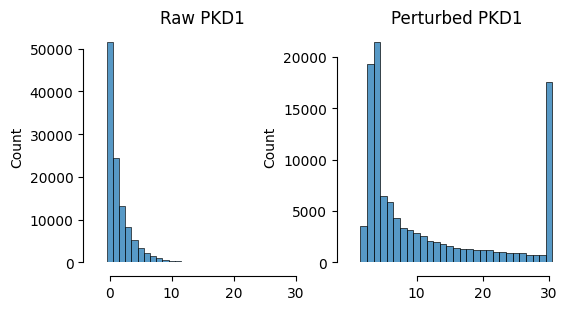

In [6]:
plot_perturbation_effect(adata, up[0])

A down-regulated gene:


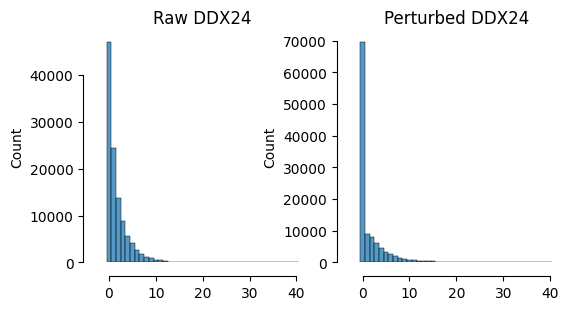

In [7]:
plot_perturbation_effect(adata, down[2])

# Saving

We save the results in a `.h5ad` file:


In [ ]:
adata.write_h5ad("adata_perturbed.h5ad")